## Logistic Regression Baseline

### Step 1: Install and Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


### Step 2: Load Dataset

In [ ]:
!pip install kaggle -q

In [ ]:
import json
import os

kaggle_api_token = ".env"
kaggle_username = ".env"

kaggle_auth_json = {
    "username": kaggle_username,
    "key": kaggle_api_token
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_auth_json, f)

print("kaggle.json created successfully in the current directory.")

kaggle.json created successfully in the current directory.
Please run the next cell to move it to the correct location and set permissions.


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -q telco-customer-churn.zip

print("Kaggle dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Kaggle dataset downloaded and unzipped successfully!


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...              

### Step 3: Data Cleaning

In [ ]:
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

# Convert TotalCharges to numeric (handles empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Remove rows with missing TotalCharges (11 rows)
df = df[df['tenure'] != 0].copy()
print(f"Dataset shape after cleaning: {df.shape}")

df = df.drop('customerID', axis=1)


DATA CLEANING
Missing values in TotalCharges: 11
Dataset shape after cleaning: (7032, 21)


### Step 4: Encode Target Variable

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Step 5: One-Hot Encoding for Categorical Variables

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"\nEncoded dataset shape: {df_encoded.shape}")


Encoded dataset shape: (7032, 31)


### Step 6: Split Features and Target

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

### Step 7: Train-Test Split (70-30)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (4922, 30)
Test set: (2110, 30)


### Step 8: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 9: Train Logistic Regression Model

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Step 10: Make Predictions

In [ ]:
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

### Step 11: Find Optimal Cutoff

In [ ]:
def find_optimal_cutoff(y_true, y_pred_proba):
    from sklearn.metrics import precision_score, recall_score

    best_cutoff = 0.5
    best_f1 = 0

    cutoffs = np.arange(0.01, 0.80, 0.01)
    results = []

    for cutoff in cutoffs:
        y_pred_cutoff = (y_pred_proba >= cutoff).astype(int)

        accuracy = accuracy_score(y_true, y_pred_cutoff)
        recall = recall_score(y_true, y_pred_cutoff)
        precision = precision_score(y_true, y_pred_cutoff)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results.append({
            'cutoff': cutoff,
            'accuracy': accuracy,
            'recall': recall,
            'precision': precision,
            'f1': f1
        })

        if f1 > best_f1:
            best_f1 = f1
            best_cutoff = cutoff

    results_df = pd.DataFrame(results)
    return best_cutoff, results_df

optimal_cutoff, cutoff_results = find_optimal_cutoff(y_test, y_pred_proba)
print(f"\n🎯 Optimal Cutoff: {optimal_cutoff:.2f}")

y_pred_optimal = (y_pred_proba >= optimal_cutoff).astype(int)


🎯 Optimal Cutoff: 0.41


### Step 12: Evaluate Model

### Logistic Regression Results (Optimal Cutoff)

Accuracy: 79.15%
Recall: 67.56%

### Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1549
           1       0.59      0.68      0.63       561

    accuracy                           0.79      2110
   macro avg       0.74      0.75      0.74      2110
weighted avg       0.80      0.79      0.80      2110


### Confusion Matrix:
[[1291  258]
 [ 182  379]]


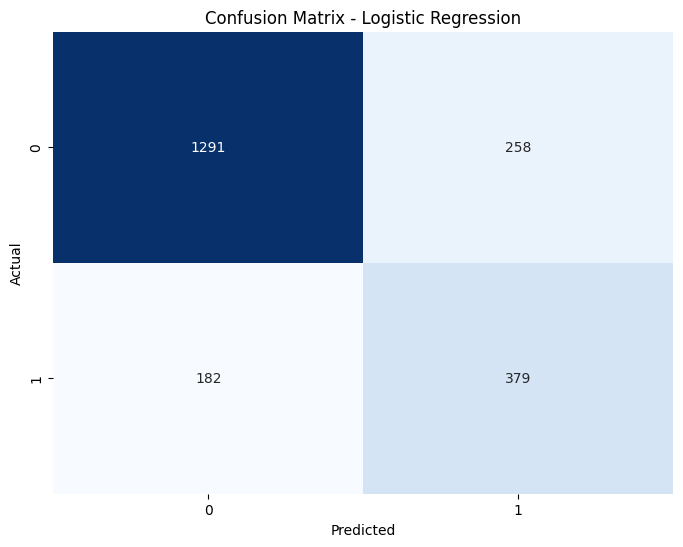

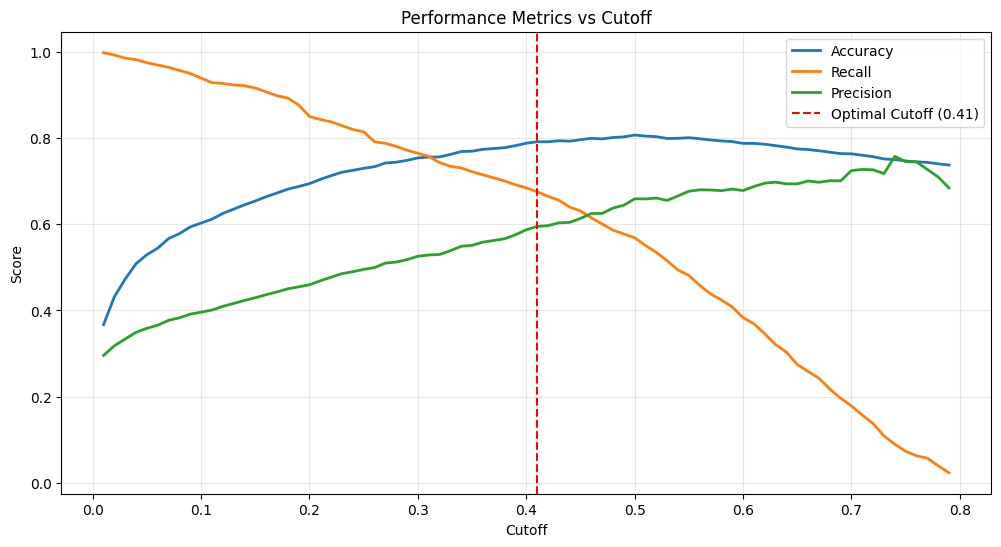


### Top 10 Most Important Features:
                           Feature  Coefficient
3                     TotalCharges     0.740914
10     InternetService_Fiber optic     0.672710
21                 StreamingTV_Yes     0.225577
9                MultipleLines_Yes     0.220639
23             StreamingMovies_Yes     0.219688
28  PaymentMethod_Electronic check     0.168436
26            PaperlessBilling_Yes     0.159581
0                    SeniorCitizen     0.063645
17            DeviceProtection_Yes     0.053195
29      PaymentMethod_Mailed check     0.041858


In [ ]:
print("### Logistic Regression Results (Optimal Cutoff)")

accuracy = accuracy_score(y_test, y_pred_optimal)
recall = recall_score(y_test, y_pred_optimal)

print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

print("\n### Classification Report:")
print(classification_report(y_test, y_pred_optimal))

print("\n### Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_optimal)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(cutoff_results['cutoff'], cutoff_results['accuracy'], label='Accuracy', linewidth=2)
plt.plot(cutoff_results['cutoff'], cutoff_results['recall'], label='Recall', linewidth=2)
plt.plot(cutoff_results['cutoff'], cutoff_results['precision'], label='Precision', linewidth=2)
plt.axvline(x=optimal_cutoff, color='red', linestyle='--', label=f'Optimal Cutoff ({optimal_cutoff:.2f})')
plt.xlabel('Cutoff')
plt.ylabel('Score')
plt.title('Performance Metrics vs Cutoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n### Top 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(feature_importance.head(10))